In [2]:
import pandas as pd 
import numpy as np

from os.path import join
import os
from tqdm import tqdm
import pandas as pd
import numpy as np


pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', 10)
from IPython.display import HTML, display
css_style = """
<style>
.scrollable {
    max-height: 1000px; 
    overflow-y: auto;
    position: relative;
}

/* Make the table header sticky */
.scrollable thead th {
    position: sticky;
    top: 0;
    background: rgba(100, 100, 100, 100); 
    z-index: 1;
}


::-webkit-scrollbar {
    -webkit-appearance: none;
}

::-webkit-scrollbar:vertical {
    width: 12px;
}

::-webkit-scrollbar-thumb {
    background-color: rgba(0, 0, 0, .5);
    border-radius: 10px;
    border: 2px solid #ffffff;
}
</style>
"""

def show(df):
    html = css_style + df.to_html(border=0)
    display(HTML('<div class="scrollable">' + html + '</div>'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


newl = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')

clinical_data = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/clinical_data/verosdata.csv')
clinical_data['taille_m'] = clinical_data['taille_cm'] / 100
clinical_data['bmi'] = clinical_data['poids_kg'] / (clinical_data['taille_m'] ** 2)
clinical_data['bmi'] = (clinical_data['bmi'] > 18.5).astype(int)
clinical_data['age'] = (clinical_data['age'] > 50).astype(int)
clinical_data['hiv_test_confirm'].fillna(1)
#clinical_data['record_id'] = clinical_data['record_id'].str.split('-').str[1].astype(int)
#clinical_data.index = clinical_data['indices']

symptoms = ['record_id','chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']
d = clinical_data[symptoms]
#show(d)
lus_interpretations = clinical_data[['record_id', 'lus_qasd_1_final',
 'lus_qasd_2_final',
 'lus_qaid_1_final',
 'lus_qsld_2_final',
 'lus_qld_1_final',
 'lus_qasg_1_final',
 'lus_qasg_2_final',
 'lus_qaig_1_final',
 'lus_qslg_2_final',
 'lus_qlg_1_final',
 'lus_qpsd_1_final',
 'lus_qpid_1_final',
 'lus_qpsg_1_final',
 'lus_qpig_1_final']]


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
def nice_plot_settings(font_size=14, font_family='STIXGeneral', mathtext_fontset='stix', usetex=False):
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 8))
    matplotlib.rcParams['mathtext.fontset'] = mathtext_fontset
    matplotlib.rcParams['font.family'] = font_family
    matplotlib.rcParams['text.usetex'] = usetex
    matplotlib.rcParams['font.size'] = font_size
    matplotlib.rcParams['axes.labelweight'] = 'bold'
    matplotlib.rcParams['axes.labelcolor'] = 'black'
    matplotlib.rcParams['axes.labelsize'] = font_size + 2
    matplotlib.rcParams['axes.titlesize'] = 'x-large'
    matplotlib.rcParams['axes.titleweight'] = 'bold'
    matplotlib.rcParams['axes.titlecolor'] = 'black'
    matplotlib.rcParams['xtick.color'] = 'black'
    matplotlib.rcParams['ytick.color'] = 'black'
    matplotlib.rcParams['legend.fontsize'] = 'medium'

nice_plot_settings()

<Figure size 1000x800 with 0 Axes>

In [3]:
import pandas as pd
from sklearn.metrics import roc_auc_score
from collections import OrderedDict
import scipy.stats
def calculate_roc_auc_scores(filename, n):
    
    # model_names = ['A-lines', 
    #           #'B-lines',
    #           'Small consolidations and or nodules',
    #           'Large Consolidations',
    #           'Pleural effusion'
    #           ]
    
    #pathology_feat, ttvsplit = filename.split('_')
    #ttvsplit = ttvsplit.split('.')[0][:-11]
    #name = pathology_feat #+ ' ' + ttvsplit
    #name = model_names[n]
    try:
        df = pd.read_csv(filename)
    except:
        return {}
    # Mapping for site indices to human-readable site names
    REVERSE_SITE_MAPPING = OrderedDict([
        (0, "<PAD>"),
        (1, "QAID"),
        (2, "QAIG"),
        (3, "QASD"),
        (4, "QASG"),
        (5, "QLD"),
        (6, "QLG"),
        (7, "QPID"),
        (8, "QPIG"),
        (9, "QPSD"),
        (10, "QPSG"),
        (11, "APXD"),
        (12, "APXG"),
        (13, "QSLD"),
        (14, "QSLG")
    ])

    df['sites'] = df['sites'].map(REVERSE_SITE_MAPPING)

    scores = {}
    for site in REVERSE_SITE_MAPPING.values():
        if site != "<PAD>":  # Exclude the padding site
            site_df = df[df['sites'] == site]
            if len(site_df['targets'].unique()) > 1:
                roc_auc = roc_auc_score(site_df['targets'], site_df['predictions_proba'])
                scores[site] = roc_auc
            else:
                scores[site] = None  # Assign None if not enough data

    # Convert scores dictionary to DataFrame with sites as columns
    #scores_df = pd.DataFrame([scores], index=[name])
    
    return scores


scores_df = pd.DataFrame()

model_names = ['A-lines', 
              'Small consolidations and or nodules',
              'Large Consolidations',
              'Pleural effusion'
              ]
model_results = {model: {site: [] for site in [
    "QAID", "QAIG", "QASD", "QASG", "QLD", "QLG", "QPID", "QPIG", "QPSD", "QPSG", "APXD", "APXG", "QSLD", "QSLG"]} 
    for model in model_names}

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

for j in range(5):
    for i, model_name in enumerate(model_names):
        #file = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat'
        #file = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds'
        file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{model_name}_Fold_{j}/{model_name}_Fold_{j}_testpredictions.csv'

        #file = file + f'/{f}_Fold_{j}_testpredictions.csv'
        site_roc_scores = calculate_roc_auc_scores(file, i)
        for site, score in site_roc_scores.items():
            if score is not None:  # Only include valid ROC AUC scores
                model_results[model_name][site].append(score)

mean_roc_auc_ci = {model: {} for model in model_names}

for model, site_scores in model_results.items():
    for site, scores in site_scores.items():
        if len(scores) > 0:
            mean_roc, lower_ci, upper_ci = mean_confidence_interval(scores)
            mean_roc_auc_ci[model][site] = {
                'Mean ROC AUC': mean_roc,
                '95% CI Lower': lower_ci,
                '95% CI Upper': upper_ci
            }

# Convert results to a DataFrame for easier display
final_results = []
        #scores_df = pd.concat([scores_df, s], axis=0)

#Calculate the mean auroc and 95% from the model results list that are saved as dictionaries within each of the model results 




#df = pd.read_csv('Normal A line Pattern_testpredictions.csv')
#scores_df = calculate_roc_auc_scores(df, filename)
#scores_df
for model, site_data in mean_roc_auc_ci.items():
    for site, metrics in site_data.items():
        final_results.append({
            'Model': model,
            'Site': site,
            'Mean ROC AUC': metrics['Mean ROC AUC'],
            '95% CI Lower': metrics['95% CI Lower'],
            '95% CI Upper': metrics['95% CI Upper']
        })

results_df = pd.DataFrame(final_results)

# Display the DataFrame
show(results_df)

,Model,Site,Mean ROC AUC,95% CI Lower,95% CI Upper
0,A-lines,QAID,0.771616,0.762831,0.780401
1,A-lines,QAIG,0.808826,0.800113,0.817539
2,A-lines,QASD,0.821472,0.807750,0.835195
3,A-lines,QASG,0.835537,0.823104,0.847970
4,A-lines,QLD,0.765429,0.752273,0.778584
5,A-lines,QLG,0.747890,0.732344,0.763435
6,A-lines,QPID,0.923261,0.915468,0.931055
7,A-lines,QPIG,0.851310,0.841960,0.860661
8,A-lines,QPSD,0.891236,0.883438,0.899033
9,A-lines,QPSG,0.934178,0.927502,0.940855


In [3]:
import pandas as pd
import numpy as np
import os
import ast
from collections import OrderedDict
REVERSE_SITE_MAPPING = OrderedDict(
    [
        (0, "<PAD>"),
        (1, "QAID"),
        (2, "QAIG"),
        (3, "QASD"),
        (4, "QASG"),
        (5, "QLD"),
        (6, "QLG"),
        (7, "QPID"),
        (8, "QPIG"),
        (9, "QPSD"),
        (10, "QPSG"),
        (11, "APXD"),
        (12, "APXG"),
        (13, "QSLD"),
        (14, "QSLG")
    ]
)

In [4]:

def create_merged_pivot_table(j):
    model_pivot_tables = [[], [],[]]
    #save_path = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat'
    save_path = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds'

    model_names = ['A-lines', 
              #'B-lines',
              'Small consolidations and or nodules',
              'Large Consolidations',
              'Pleural effusion'
              ]

    def extract_middle_piece(indices):
    # Strip the square brackets and return the middle piece
        return indices.strip('['']')
    
 
    for model_name in model_names:
        train_file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{model_name}_Fold_{j}/{model_name}_Fold_{j}_trainpredictions.csv'
        valid_file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{model_name}_Fold_{j}/{model_name}_Fold_{j}_validpredictions.csv'
        test_file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{model_name}_Fold_{j}/{model_name}_Fold_{j}_validpredictions.csv'

        # train_file = os.path.join(save_path , f"{model_name}_trainpredictions.csv")
        # valid_file = os.path.join(save_path , f"{model_name}_validpredictions.csv")
        # test_file = os.path.join(save_path , f"{model_name}_testpredictions.csv")
        file_paths = [train_file, valid_file, test_file]
        
        # Process each file
        for i in range(len(file_paths)):
            file_path = file_paths[i]
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                df = df[df['sites'] != 0]
                df['sites'] = df['sites'].map(REVERSE_SITE_MAPPING)
                pred_pivot_df = df.pivot_table(index='indices', columns='sites', values='predictions_proba', aggfunc='mean').fillna(0)
                pred_pivot_df.columns = [f"{col}_{model_name}" for col in pred_pivot_df.columns]
                model_pivot_tables[i].append(pred_pivot_df)


    model_pivot_tables = [pd.concat(tables, axis=1) for tables in model_pivot_tables]
    #clinician_pivot_tables = [pd.concat(tables, axis=1) for tables in clinician_pivot_tables]
    for i in range(len(model_pivot_tables)):
        model_pivot_tables[i] = model_pivot_tables[i].fillna(0)
        model_pivot_tables[i] = model_pivot_tables[i].reset_index()
        model_pivot_tables[i]['record_id'] = model_pivot_tables[i]['indices'].apply(extract_middle_piece).str.strip("'")
        model_pivot_tables[i] = model_pivot_tables[i].drop(columns = ['indices'])


    return model_pivot_tables

for i in range(5):
    model_tables = create_merged_pivot_table(i)
    model_tables[0].to_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{i}_trainpredictions.csv')
    model_tables[1].to_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{i}_validpredictions.csv')
    model_tables[2].to_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{i}_testpredictions.csv')

In [5]:
import pandas as pd
import os

# Helper function to extract middle piece from string indices
def extract_middle_piece(indices):
    if isinstance(indices, str):  # Ensure it's a string before applying strip
        return indices.strip('['']')
    return indices

# List of model names
model_names = ['A-lines', 
              'Small consolidations and or nodules',
              'Large Consolidations',
              'Pleural effusion']

# Loop through each model
for m in model_names:
    models = []
    
    # Loop through each fold (5 folds)
    for f in range(5):
        print(file)
        file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{m}_Fold_{f}/{m}_Fold_{f}_testpredictions.csv'
        
        # Check if the file exists before proceeding
        if not os.path.exists(file):
            print(f"File not found: {file}")
            continue  # Skip this file and continue with the next fold
        
        try:
            # Read CSV file
            data = pd.read_csv(file)
            
            # Ensure the required columns are present
            if 'indices' not in data.columns or 'targets' not in data.columns or 'predictions_proba' not in data.columns:
                print(f"Missing columns in file: {file}")
                continue  # Skip this file if columns are missing
            
            # Create a new DataFrame with relevant columns
            new_df = data[['indices', 'targets', 'predictions_proba']]
            
            # Initialize final_new_df for each fold
            final_new_df = pd.DataFrame()
            
            # Apply the extraction and strip the middle piece of the 'record_id'
            final_new_df['record_id'] = new_df['indices'].apply(extract_middle_piece).str.strip("'")
            
            # Add target and prediction columns for the current fold
            final_new_df[f'{m}_Fold_{f}_y'] = new_df['targets']
            final_new_df[f'{m}_Fold_{f}_preds'] = new_df['predictions_proba']
            
            # Append this DataFrame to the list for merging later
            models.append(final_new_df)
        
        except Exception as e:
            print(f"Error processing file {file}: {e}")
            continue  # Skip this file if an error occurs
    
    # Check if there are any models to merge
    if len(models) == 0:
        print(f"No data to merge for model: {m}")
        continue
    
    # Merge all 5 folds into one DataFrame based on 'record_id'
    try:
        first_model = models[0]
        for i in range(1, len(models)):  # Start from the second DataFrame
            first_model = pd.merge(first_model, models[i], left_on='record_id', right_on='record_id', how='outer')
        
        # Save the final merged DataFrame for the current model
        first_model.to_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/{m}.csv', index=False)
        print(f"Successfully saved: {m}.csv")
    
    except Exception as e:
        print(f"Error merging or saving for model {m}: {e}")

/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/Pleural effusion_Fold_4/Pleural effusion_Fold_4_testpredictions.csv
/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/A-lines_Fold_0/A-lines_Fold_0_testpredictions.csv
/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/A-lines_Fold_1/A-lines_Fold_1_testpredictions.csv
/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/A-lines_Fold_2/A-lines_Fold_2_testpredictions.csv
/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/A-lines_Fold_3/A-lines_Fold_3_testpredictions.csv


: 

: 

[0.8515997187129084, 0.860211841197351, 0.854335041598961, 0.8592027348509562, 0.8598175478817405]


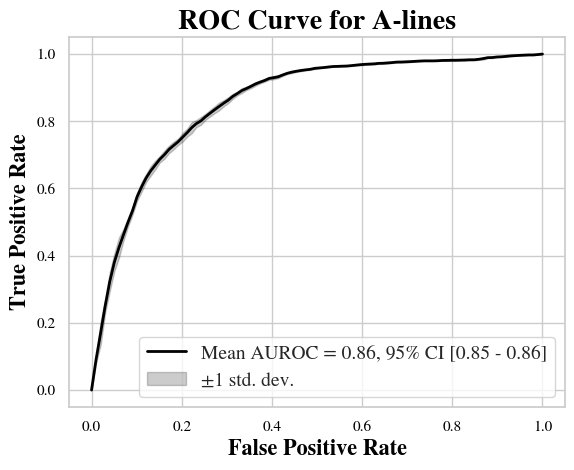

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, auc
from matplotlib.patches import Patch

def print_auroc_curve(m):
    folds = [0, 1, 2, 3, 4]

    fpr_list = []
    tpr_list = []
    mean_fpr = np.linspace(0, 1, 100)
    aucs = []

    fig, ax = plt.subplots()
    for f in folds:
        file = f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/{m}_Fold_{f}/{m}_Fold_{f}_testpredictions.csv'
        data = pd.read_csv(file)
        y_true = data['targets']
        y_pred = data['predictions_proba']
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0  # Ensure the curve starts at 0
        
        fpr_list.append(mean_fpr)
        tpr_list.append(tpr_interp)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

    print(aucs)

    mean_tpr = np.mean(tpr_list, axis=0)
    mean_tpr[-1] = 1.0  
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    tpr_std = np.std(tpr_list, axis=0)
    tpr_lower = mean_tpr - tpr_std
    tpr_upper = mean_tpr + tpr_std

    # Compute the mean AUC and 95% CI for AUC
    mean_auc = np.mean(aucs)
    ci_lower_auc = np.percentile(aucs, 2.5)
    ci_upper_auc = np.percentile(aucs, 97.5)
    ax.plot(mean_fpr, mean_tpr, color='black', lw=2, 
            label=f'Mean AUROC = {mean_auc:.2f}, 95% CI [{ci_lower_auc:.2f} - {ci_upper_auc:.2f}]')
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color='black', alpha=0.2, 
                    label='±1 std. dev.')

    # Plotting options
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve for {m}')
    ax.legend(loc='lower right')

    plt.show()


print_auroc_curve('A-lines')


In [6]:
model_tables[0].to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_trainpredictions1.csv')
model_tables[1].to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_validpredictions1.csv')
model_tables[2].to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_testpredictions1.csv')

In [5]:
train_ids_set = set(train['record_id'].unique())
valid_ids_set = set(valid['record_id'].unique())
test_ids_set = set(test['record_id'].unique())

# Check for overlaps
train_valid_overlap = train_ids_set.intersection(valid_ids_set)
train_test_overlap = train_ids_set.intersection(test_ids_set)
valid_test_overlap = valid_ids_set.intersection(test_ids_set)

# Raise an error if any overlap is found
if train_valid_overlap:
    raise ValueError(f"Overlap found between train and valid sets: {train_valid_overlap}")
if train_test_overlap:
    raise ValueError(f"Overlap found between train and test sets: {train_test_overlap}")
if valid_test_overlap:
    raise ValueError(f"Overlap found between valid and test sets: {valid_test_overlap}")

print("No overlap found between train, valid, and test sets.")

NameError: name 'train' is not defined

In [9]:
test = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{4}_testpredictions.csv')
show(test)

,Unnamed: 0,APXD_A-lines,APXG_A-lines,QAID_A-lines,QAIG_A-lines,QASD_A-lines,QASG_A-lines,QLD_A-lines,QLG_A-lines,QPID_A-lines,QPIG_A-lines,QPSD_A-lines,QPSG_A-lines,QSLD_A-lines,QSLG_A-lines,APXD_Small consolidations and or nodules,APXG_Small consolidations and or nodules,QAID_Small consolidations and or nodules,QAIG_Small consolidations and or nodules,QASD_Small consolidations and or nodules,QASG_Small consolidations and or nodules,QLD_Small consolidations and or nodules,QLG_Small consolidations and or nodules,QPID_Small consolidations and or nodules,QPIG_Small consolidations and or nodules,QPSD_Small consolidations and or nodules,QPSG_Small consolidations and or nodules,QSLD_Small consolidations and or nodules,QSLG_Small consolidations and or nodules,APXD_Large Consolidations,APXG_Large Consolidations,QAID_Large Consolidations,QAIG_Large Consolidations,QASD_Large Consolidations,QASG_Large Consolidations,QLD_Large Consolidations,QLG_Large Consolidations,QPID_Large Consolidations,QPIG_Large Consolidations,QPSD_Large Consolidations,QPSG_Large Consolidations,QSLD_Large Consolidations,QSLG_Large Consolidations,APXD_Pleural effusion,APXG_Pleural effusion,QAID_Pleural effusion,QAIG_Pleural effusion,QASD_Pleural effusion,QASG_Pleural effusion,QLD_Pleural effusion,QLG_Pleural effusion,QPID_Pleural effusion,QPIG_Pleural effusion,QPSD_Pleural effusion,QPSG_Pleural effusion,QSLD_Pleural effusion,QSLG_Pleural effusion,record_id
0,0,0.476995,0.948664,0.575866,0.689712,0.017665,0.876563,0.919069,0.205767,0.060777,0.887858,0.532439,0.757302,0.422248,0.729146,0.460884,0.151714,0.684412,0.441397,0.617741,0.205543,0.393531,0.624771,0.770278,0.327237,0.544428,0.217953,0.496804,0.405822,0.045800,0.014273,0.010300,0.008344,0.474681,0.019083,0.014582,0.020772,0.104154,0.019184,0.102900,0.035901,0.115408,0.022389,0.060756,0.037387,0.056804,0.042682,0.241588,0.067066,0.339726,0.627344,0.124976,0.056574,0.084212,0.114899,0.103742,0.045944,25-102
1,1,0.894647,0.886775,0.674543,0.254804,0.653971,0.817349,0.768232,0.050338,0.890632,0.928736,0.925889,0.960439,0.000000,0.890697,0.354224,0.390427,0.419412,0.675538,0.448207,0.329522,0.344249,0.605279,0.233971,0.115853,0.194279,0.079752,0.000000,0.124326,0.013975,0.025958,0.010180,0.010008,0.011656,0.015268,0.009435,0.116825,0.017568,0.012139,0.027490,0.030164,0.000000,0.015421,0.077999,0.021803,0.022603,0.035580,0.052969,0.038151,0.288304,0.748830,0.129193,0.023534,0.063404,0.058690,0.000000,0.071434,25-111
2,2,0.013577,0.015679,0.394225,0.010443,0.399948,0.012755,0.668240,0.013896,0.896768,0.404166,0.205498,0.051028,0.047205,0.033207,0.619446,0.393412,0.536204,0.642850,0.565791,0.525820,0.455568,0.856322,0.187433,0.624312,0.630232,0.577873,0.442436,0.780315,0.314567,0.769221,0.073034,0.959705,0.023830,0.626706,0.034525,0.064464,0.047973,0.027921,0.414379,0.486355,0.573547,0.352284,0.159374,0.230035,0.044256,0.038745,0.079562,0.064390,0.767227,0.685920,0.136469,0.056529,0.176814,0.114813,0.062096,0.100437,25-117
3,3,0.877486,0.923933,0.748553,0.826201,0.747007,0.836372,0.788323,0.708047,0.000000,0.000000,0.000000,0.000000,0.922851,0.871362,0.138672,0.124392,0.495539,0.287379,0.356090,0.237703,0.182460,0.138968,0.000000,0.000000,0.000000,0.000000,0.123883,0.252556,0.065449,0.008715,0.010041,0.011479,0.012861,0.021443,0.011071,0.037570,0.000000,0.000000,0.000000,0.000000,0.071651,0.022419,0.045482,0.027070,0.067391,0.031172,0.095072,0.042189,0.533536,0.568116,0.000000,0.000000,0.000000,0.000000,0.039258,0.063705,25-119
4,4,0.023732,0.000000,0.331168,0.000000,0.022356,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.954392,0.000000,0.714944,0.000000,0.916803,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050946,0.000000,0.013737,0.000000,0.046170,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046674,0.000000,0.042601,0.000000,0.072988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000

In [4]:

def combine_columns_max(df, pattern, quadrants):
    columns = [f"{q}_{pattern}" for q in quadrants]
    return df[columns].max(axis=1)
patterns = ['A-lines', 'Small consolidations and or nodules', 'Large Consolidations', 'Pleural effusion']
def create_tables(fold):
    ids = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Splits_stratified/Fold_{fold}.csv')
    labels = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')
    labels = labels[['record_id', 'TB Label']]
    apical_quadrants = ['APXD', 'APXG', 'QPID', 'QPIG']
    anterior_quadrants = ['QASD', 'QAID', 'QASG', 'QAIG']
    posterior_quadrants = ['QPSD', 'QPSG', 'QLD', 'QLG']
    lateral_quadrants = ['QSLD', 'QSLG']
    non_apical_quadrant = anterior_quadrants + posterior_quadrants + lateral_quadrants

    train = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{fold}_trainpredictions.csv')
    valid = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{fold}_validpredictions.csv')
    test = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Path_Strat_Folds/Preds/AIML_Folds/AIML_Fold_{fold}_testpredictions.csv')
    train = pd.merge(train, labels, left_on='record_id', right_on='record_id')
    valid = pd.merge(valid, labels, left_on='record_id', right_on='record_id')
    test = pd.merge(test, labels, left_on='record_id', right_on='record_id')

    train_combined_df = pd.DataFrame()
    train_combined_df['record_id'] = ids['train_ids']
    train_combined_df = pd.merge(train_combined_df, labels, left_on='record_id', right_on='record_id', how='inner')

    valid_combined_df = pd.DataFrame()
    valid_combined_df['record_id'] = ids['valid_ids']
    valid_combined_df = pd.merge(valid_combined_df, labels, left_on='record_id', right_on='record_id', how = 'inner')


    test_combined_df = pd.DataFrame()
    test_combined_df['record_id'] = ids['test_ids']
    test_combined_df = pd.merge(test_combined_df, labels, left_on='record_id', right_on='record_id', how = 'inner')


    #combined_df['TB Label'] = newlmv['TB Label']

    for pattern in patterns:
        train_combined_df[f"{pattern}_Apical"] = combine_columns_max(train, pattern, apical_quadrants)
        train_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(train, pattern, non_apical_quadrant)
        valid_combined_df[f"{pattern}_Apical"] = combine_columns_max(valid, pattern, apical_quadrants)
        valid_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(valid, pattern, non_apical_quadrant)
        test_combined_df[f"{pattern}_Apical"] = combine_columns_max(test, pattern, apical_quadrants)
        test_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(test, pattern, non_apical_quadrant)

    train = train_combined_df
    valid = valid_combined_df
    test = test_combined_df

    train.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_train.csv')
    valid.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_valid.csv')
    test.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_test.csv')



    return train, valid, test


train, valid, test = create_tables(2)

show(test)

,record_id,TB Label,A-lines_Apical,A-lines_AnyQuadrant,Small consolidations and or nodules_Apical,Small consolidations and or nodules_AnyQuadrant,Large Consolidations_Apical,Large Consolidations_AnyQuadrant,Pleural effusion_Apical,Pleural effusion_AnyQuadrant
0,25-581,0,0.911041,0.926367,0.504988,0.851455,0.040383,0.836086,0.398648,0.495982
1,25-398,0,0.916855,0.898084,0.314553,0.638304,0.902731,0.744622,0.319975,0.667575
2,25-631,1,0.861362,0.882356,0.243629,0.792399,0.014567,0.980594,0.225705,0.581794
3,25-446,1,0.434458,0.885173,0.333233,0.130749,0.376456,0.962678,0.291387,0.704926
4,25-190,1,0.531380,0.911638,0.671436,0.359889,0.030999,0.229899,0.186326,0.639680
5,25-331,0,0.777262,0.946532,0.743431,0.815116,0.156804,0.186634,0.198829,0.538227
6,25-455,1,0.880281,0.953120,0.225669,0.485004,0.021813,0.496157,0.213044,0.474368
7,25-498,0,0.049573,0.062400,0.056237,0.180270,0.982394,0.950631,0.240986,0.282805
8,25-739,1,0.877630,0.917616,0.752020,0.790477,0.961086,0.943310,0.581281,0.709586
9,25-736,0,0.954955,0.980736,0.210718,0.513932,0.022855,0.734179,0.294925,0.470152


In [10]:
test = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_testpredictions1.csv')
test

,Unnamed: 0,APXD_A-lines,APXG_A-lines,QAID_A-lines,QAIG_A-lines,QASD_A-lines,QASG_A-lines,QLD_A-lines,QLG_A-lines,QPID_A-lines,QPIG_A-lines,QPSD_A-lines,QPSG_A-lines,QSLD_A-lines,QSLG_A-lines,APXD_Small consolidations and or nodules,APXG_Small consolidations and or nodules,QAID_Small consolidations and or nodules,QAIG_Small consolidations and or nodules,QASD_Small consolidations and or nodules,QASG_Small consolidations and or nodules,QLD_Small consolidations and or nodules,QLG_Small consolidations and or nodules,QPID_Small consolidations and or nodules,QPIG_Small consolidations and or nodules,QPSD_Small consolidations and or nodules,QPSG_Small consolidations and or nodules,QSLD_Small consolidations and or nodules,QSLG_Small consolidations and or nodules,APXD_Large Consolidations,APXG_Large Consolidations,QAID_Large Consolidations,QAIG_Large Consolidations,QASD_Large Consolidations,QASG_Large Consolidations,QLD_Large Consolidations,QLG_Large Consolidations,QPID_Large Consolidations,QPIG_Large Consolidations,QPSD_Large Consolidations,QPSG_Large Consolidations,QSLD_Large Consolidations,QSLG_Large Consolidations,APXD_Pleural effusion,APXG_Pleural effusion,QAID_Pleural effusion,QAIG_Pleural effusion,QASD_Pleural effusion,QASG_Pleural effusion,QLD_Pleural effusion,QLG_Pleural effusion,QPID_Pleural effusion,QPIG_Pleural effusion,QPSD_Pleural effusion,QPSG_Pleural effusion,QSLD_Pleural effusion,QSLG_Pleural effusion,record_id
0,0,0.373912,0.795436,0.671338,0.188460,0.490694,0.009023,0.017655,0.054533,0.015477,0.021222,0.062702,0.009003,0.657974,0.914660,0.373572,0.196097,0.309537,0.360671,0.505229,0.799727,0.227149,0.296058,0.169348,0.076874,0.506965,0.617651,0.265762,0.109591,0.061271,0.034355,0.002686,0.619551,0.027020,0.268151,0.107483,0.970911,0.536288,0.875689,0.145556,0.601948,0.023343,0.025755,0.000512,0.000995,0.002008,0.000186,0.002842,0.000201,0.996679,0.790695,0.692631,0.488580,0.002109,0.002797,0.000171,0.005958,25-103
1,1,0.842514,0.806028,0.467237,0.560073,0.216025,0.627102,0.529224,0.342911,0.009998,0.874566,0.189753,0.017595,0.772774,0.047116,0.070431,0.143351,0.402462,0.290120,0.575652,0.346224,0.207072,0.393203,0.764597,0.101564,0.256656,0.117228,0.114338,0.616755,0.006329,0.035145,0.003987,0.026759,0.032371,0.005492,0.014185,0.276776,0.049824,0.024039,0.677146,0.779555,0.039564,0.564623,0.000684,0.000860,0.001660,0.001663,0.006647,0.000618,0.057140,0.391501,0.004177,0.043887,0.003959,0.001094,0.007169,0.001603,25-106
2,2,0.117279,0.456725,0.281575,0.413305,0.335378,0.276180,0.718604,0.104137,0.389162,0.476958,0.523137,0.172995,0.298781,0.821372,0.600784,0.663260,0.535498,0.351444,0.637605,0.440944,0.144267,0.635082,0.112875,0.231392,0.119903,0.174760,0.357434,0.137415,0.468312,0.043743,0.077602,0.089771,0.050126,0.006130,0.007984,0.432445,0.039764,0.013651,0.079828,0.068816,0.219063,0.008681,0.000275,0.000216,0.001794,0.001679,0.001209,0.001566,0.427433,0.022127,0.001062,0.002383,0.000178,0.000135,0.000384,0.001991,25-108
3,3,0.534305,0.008820,0.226101,0.079578,0.278725,0.008556,0.334937,0.009132,0.074983,0.359013,0.470585,0.419020,0.800115,0.014058,0.190836,0.819578,0.650771,0.646967,0.697918,0.787884,0.547150,0.720097,0.576992,0.202242,0.267407,0.380464,0.090687,0.781093,0.005240,0.041110,0.025968,0.060910,0.013634,0.036695,0.009333,0.323353,0.102457,0.119091,0.347381,0.101780,0.010850,0.459004,0.003542,0.009002,0.000637,0.000119,0.000255,0.000808,0.046747,0.066154,0.001065,0.011172,0.001178,0.000435,0.000854,0.000224,25-120
4,4,0.009315,0.826678,0.584745,0.380638,0.749301,0.824675,0.537912,0.019575,0.609360,0.270755,0.888605,0.872982,0.936866,0.924260,0.795829,0.172106,0.311278,0.528650,0.419572,0.244891,0.674387,0.665019,0.103172,0.113339,0.064982,0.057624,0.055458,0.070756,0.180267,0.012976,0.017481,0.080878,0.034523,0.012024,0.013436,0.851058,0.079206,0.435617,0.069587,0.100385,0.006031,0.001663,0.000247,0.000456,0.004023,0.000701,0.001073,0.002021,0.006159,0.202862,0.002525,0.002220,0.001539,0.001046,0.002485

In [18]:
apical_quadrants = ['APXD', 'APXG', 'QPID', 'QPIG']
anterior_quadrants = ['QASD', 'QAID', 'QASG', 'QAIG']
posterior_quadrants = ['QPSD', 'QPSG', 'QLD', 'QLG']
lateral_quadrants = ['QSLD', 'QSLG']
non_apical_quadrant = anterior_quadrants + posterior_quadrants + lateral_quadrants


train = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_trainpredictions1.csv')
valid = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_validpredictions1.csv')
test = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/PredictionsPath_strat/AIML_testpredictions1.csv')
labels = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')
labels = labels[['record_id', 'TB Label']]

train = pd.merge(train, labels, left_on='record_id', right_on='record_id')
valid = pd.merge(valid, labels, left_on='record_id', right_on='record_id')
test = pd.merge(test, labels, left_on='record_id', right_on='record_id')

patterns = ['A-lines', 'Small consolidations and or nodules', 'Large Consolidations', 'Pleural effusion'] #'B-lines',

def combine_columns_max(df, pattern, quadrants):
    columns = [f"{q}_{pattern}" for q in quadrants]
    return df[columns].max(axis=1)

train_combined_df = pd.DataFrame()
train_combined_df['record_id'] = train['record_id']
train_combined_df = pd.merge(train_combined_df, labels, left_on='record_id', right_on='record_id')

valid_combined_df = pd.DataFrame()
valid_combined_df['record_id'] = valid['record_id']
valid_combined_df = pd.merge(valid_combined_df, labels, left_on='record_id', right_on='record_id')


test_combined_df = pd.DataFrame()
test_combined_df['record_id'] = test['record_id']
test_combined_df = pd.merge(test_combined_df, labels, left_on='record_id', right_on='record_id')


#combined_df['TB Label'] = newlmv['TB Label']

for pattern in patterns:
    train_combined_df[f"{pattern}_Apical"] = combine_columns_max(train, pattern, apical_quadrants)
    train_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(train, pattern, non_apical_quadrant)
    valid_combined_df[f"{pattern}_Apical"] = combine_columns_max(valid, pattern, apical_quadrants)
    valid_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(valid, pattern, non_apical_quadrant)
    test_combined_df[f"{pattern}_Apical"] = combine_columns_max(test, pattern, apical_quadrants)
    test_combined_df[f"{pattern}_AnyQuadrant"] = combine_columns_max(test, pattern, non_apical_quadrant)


#train_combined_df

train = train_combined_df
valid = valid_combined_df
test = test_combined_df


clinical_data = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/clinical_data/verosdata.csv')
clinical_data['taille_m'] = clinical_data['taille_cm'] / 100
clinical_data['bmi'] = clinical_data['poids_kg'] / (clinical_data['taille_m'] ** 2)
clinical_data['bmi'] = (clinical_data['bmi'] > 18.5).astype(int)
clinical_data['age'] = (clinical_data['age'] > 50).astype(int)
clinical_data['hiv_test_confirm'].fillna(1)
#clinical_data['record_id'] = clinical_data['record_id'].str.split('-').str[1].astype(int)
#clinical_data.index = clinical_data['indices']

symptoms = ['record_id','chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']
d = clinical_data[symptoms].fillna(0)

# train = pd.merge(train, d, left_on='record_id', right_on='record_id')
# valid = pd.merge(valid, d, left_on='record_id', right_on='record_id')
# test = pd.merge(test, d, left_on='record_id', right_on='record_id')


clin_df = ['record_id', 'TB Label', 'chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']

# train = train.drop(columns = clin_df)
# valid = valid.drop(columns = clin_df)
# test = test.drop(columns = clin_df)

In [19]:
test.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_testcombined.csv')
valid.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_validcombined.csv')
train.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_traincombined.csv')

In [ ]:
X_train_orig, y_train, y_train_ids = train.drop(columns=['record_id', 'TB Label']), train['TB Label'], train['record_id']
X_valid, y_valid, y_valid_ids = valid.drop(columns=['record_id', 'TB Label']), valid['TB Label'], valid['record_id']
X_test, y_test_m, y_test_ids = test.drop(columns=['record_id', 'TB Label']), test['TB Label'], test['record_id']

X_train_full = pd.concat([X_train_orig, X_valid])
y_train_full = pd.concat([y_train, y_valid])



0     25-101
1     25-104
2     25-109
3     25-110
4     25-112
       ...  
75    25-750
76    25-757
77    25-763
78     25-79
79     25-88
Name: record_id, Length: 401, dtype: object

Random Forest 0.8955722639933167
Random Forest 0.9035087719298246
Random Forest 0.9131161236424395
Model: Random Forest
Mean AUROC on Test Set: 0.902
95% CI for AUROC on Test Set: [0.890, 0.914]
Logistic Regression 0.8784461152882206
Logistic Regression 0.8796992481203008
Logistic Regression 0.8905597326649959
Model: Logistic Regression
Mean AUROC on Test Set: 0.878
95% CI for AUROC on Test Set: [0.867, 0.888]


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:31] WARNING: /workspace/src/lea

XGBoost 0.8732247284878866


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:33] WARNING: /workspace/src/lea

XGBoost 0.8809523809523809


/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/tjb76/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:34:35] WARNING: /workspace/src/lea

Model: XGBoost
Mean AUROC on Test Set: 0.870
95% CI for AUROC on Test Set: [0.861, 0.879]


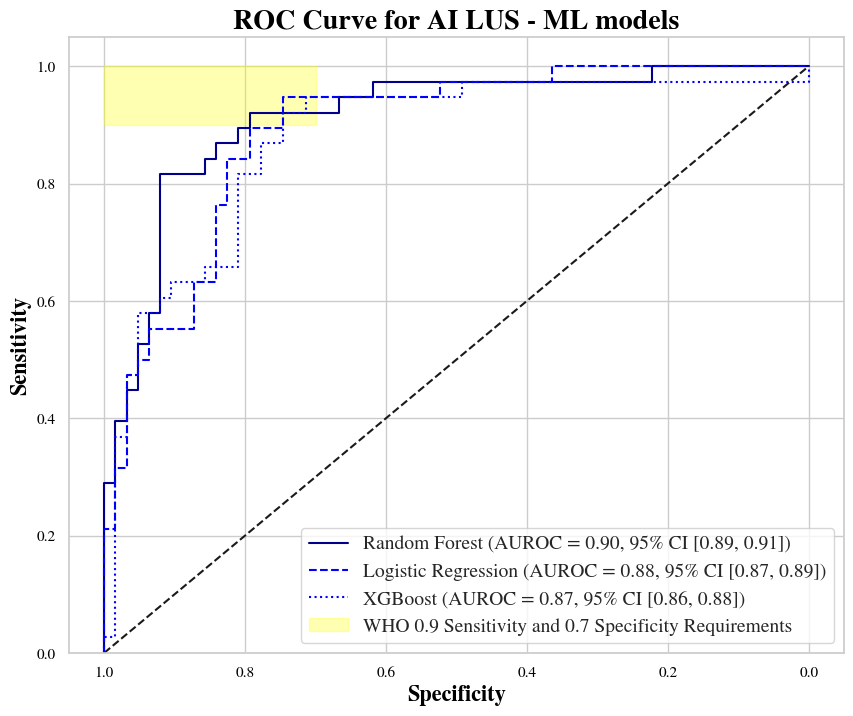

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import pickle
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import scipy.stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h


X_train_orig, y_train, y_train_ids = train.drop(columns=['record_id', 'TB Label']), train['TB Label'], train['record_id']
X_valid, y_valid, y_valid_ids = valid.drop(columns=['record_id', 'TB Label']), valid['TB Label'], valid['record_id']
X_test, y_test_m, y_test_ids = test.drop(columns=['record_id', 'TB Label']), test['TB Label'], test['record_id']

X_train_full = pd.concat([X_train_orig, X_valid])
y_train_full = pd.concat([y_train, y_valid])
X_train_ids = pd.concat([y_train_ids, y_valid_ids])


# scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)


# Define parameter grids for each model
param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

param_grid_lgb = {
    'lgb__n_estimators': [50, 100, 200],
    'lgb__learning_rate': [0.01, 0.1, 0.2],
    'lgb__max_depth': [3, 5, 7]
}

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}

param_grid_ab = {
    'ab__n_estimators': [50, 100, 200],
    'ab__learning_rate': [0.01, 0.1, 0.2]
}

param_grid_cb = {
    'cb__iterations': [50, 100, 200],
    'cb__learning_rate': [0.01, 0.1, 0.2],
    'cb__depth': [3, 5, 7]
}

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100]
}

# Create model pipelines
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10000))
])

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

ab_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ab', AdaBoostClassifier())
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgb', lgb.LGBMClassifier())
])

cb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('cb', CatBoostClassifier(verbose=0))
])

models = {
    'Random Forest': (rf_pipeline, param_grid_rf),
    #'AdaBoost': (ab_pipeline, param_grid_ab),
    #'CatBoost': (cb_pipeline, param_grid_cb),
    'Logistic Regression': (lr_pipeline, param_grid_lr),
    'XGBoost': (xgb_pipeline, param_grid_xgb),
    #'LightGBM': (lgb_pipeline, param_grid_lgb)
}

# Initialize StratifiedKFold
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

rf_folds_test_preds = pd.DataFrame()
rf_folds_test_preds['record_id'] = y_test_ids

folds_preds_df = pd.DataFrame()
folds_preds_df['record_id'] = y_test_ids
folds_preds_df['TB Label'] = y_test_m

results = {}
best_models = {}

predictions = {}
train_predictions = {}  # Fill this with your out-of-fold predictions for training data
valid_predictions = {}  # Fill this with predictions for the validation splits



for model_name, (pipeline, param_grid) in models.items():
    test_aurocs = []
    fold_predictions = []
    best_test_auc = 0
    for fold, (train_index, valid_index) in enumerate(skf.split(X_train_full, y_train_full)):
        X_train_fold, X_valid_fold = X_train_full[train_index], X_train_full[valid_index]
        y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]
        
        grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                                   scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_fold, y_train_fold)
        
        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)
        

        if test_auc > best_test_auc:
            print(model_name, test_auc)
            best_test_auc = test_auc
            best_models[model_name] = best_model

        folds_preds_df[f'{model_name}_Fold_{fold}'] = y_test_pred_proba

    
    mean_auc, ci_lower, ci_upper = mean_confidence_interval(test_aurocs)
    results[model_name] = (mean_auc, ci_lower, ci_upper)
    
    print(f"Model: {model_name}")
    print(f"Mean AUROC on Test Set: {mean_auc:.3f}")
    print(f"95% CI for AUROC on Test Set: [{ci_lower:.3f}, {ci_upper:.3f}]")


# Evaluate the best models on the test set
predictions = {}
train_predictions = {}
valid_predictions = {}
for model_name, (mean_auc, ci_lower, ci_upper) in results.items():
    model = best_models[model_name]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred_proba

    train_pred_proba =  model.predict_proba(X_train_full)[:, 1]
    train_predictions[model_name] = train_pred_proba

# Save predictions to a file
with open('model_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Plot the AUROC curve

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

plt.figure(figsize=(10, 8))

results_df = pd.DataFrame({
    'record_id': y_test_ids,
    'y_test': y_test_m
})

train_results_df = pd.DataFrame({
    'record_id': X_train_ids,
    'y_test': y_train_full
})

colors = {
    'Random Forest': '#00008B',  # Dark Blue
    'Logistic Regression': '#0000FF',  # Medium Blue
    'XGBoost': '#0000FF'  # Light Blue
}

linestyles = {
    'Random Forest': '-',
    'Logistic Regression': '--',
    'XGBoost': ':'
}

for model_name, y_pred_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test_m, y_pred_proba)
    mean_auc, ci_lower, ci_upper = results[model_name]
    results_df[f'{model_name}_pred_proba'] = y_pred_proba
    results_df[f'{model_name}_fpr'] = pd.Series(fpr, index=results_df.index[:len(fpr)])
    results_df[f'{model_name}_tpr'] = pd.Series(tpr, index=results_df.index[:len(tpr)])
    plt.plot(fpr, tpr, label=f'{model_name} (AUROC = {mean_auc:.2f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}])', color=colors[model_name], linestyle=linestyles[model_name], drawstyle='steps-post')



for model_name, y_pred_proba in train_predictions.items():
    train_results_df[f'{model_name}_pred_proba'] = y_pred_proba


plt.plot([0, 1], [0, 1], 'k--')
highlight = plt.axvspan(0, 0.3, ymin=0.9/1.05, ymax=1/1.05, color='yellow', alpha=0.3)


highlight_patch = Patch(color='yellow', alpha=0.3, label='WHO 0.9 Sensitivity and 0.7 Specificity Requirements')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles + [highlight_patch], loc="lower right")

xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xtick_labels = ['1.0', '0.8', '0.6', '0.4', '0.2', '0.0']
plt.xticks(xticks, labels=xtick_labels)
#plt.xlim([0.0, 1.0])
plt.xticks(xticks)
plt.ylim([0.0, 1.05])
plt.xlabel('Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve for AI LUS - ML models')
plt.savefig('auroc_curve_aimlmodels.png')
plt.show()

In [8]:
# results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/aiml_randomforestresults3.csv')
# folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')

# results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clin_randomforestresults2.csv')
# folds_preds_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clinFoldsPreds3.csv')

In [34]:
results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_testresults.csv')

In [33]:
train_results_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/CXR_Comp_Files/aiml_trainresults.csv')

In [17]:
transformed_data = {
    'Model Name': ['Random Forest', 'Xgboost',  'Logistic Regression',],
    'Mean AUROC': [
        results['Random Forest'][0],
        results['XGBoost'][0],
        results['Logistic Regression'][0]
    ],
    'Lower CI': [
        results['Random Forest'][1],
        results['XGBoost'][1],
        results['Logistic Regression'][1]
    ],
    'Upper CI': [
        results['Random Forest'][2],
        results['XGBoost'][2],
        results['Logistic Regression'][2]
    ]
}
transformed_data
df = pd.DataFrame(transformed_data)
df


,Model Name,Mean AUROC,Lower CI,Upper CI
0,Random Forest,0.898162,0.882407,0.913917
1,Xgboost,0.869967,0.860570,0.879363
2,Logistic Regression,0.877778,0.867278,0.888277


In [23]:
rf_model = best_models['Random Forest'].named_steps['rf']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train_orig.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feature_importance_df.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/RandomForestFeatureImportances2.csv')
show(feature_importance_df)

,Feature,Importance
5,Large Consolidations_AnyQuadrant,0.323860
4,Large Consolidations_Apical,0.262034
1,A-lines_AnyQuadrant,0.149921
0,A-lines_Apical,0.088876
2,Small consolidations and or nodules_Apical,0.086849
6,Pleural effusion_Apical,0.030668
3,Small consolidations and or nodules_AnyQuadrant,0.030622
7,Pleural effusion_AnyQuadrant,0.027169


In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pickle

# Define your initial feature set
features = feature_importance_df['Feature'].tolist()

X_train_orig, y_train, y_train_ids = train[features], train['TB Label'], train['record_id']
X_valid, y_valid, y_valid_ids = valid[features], valid['TB Label'], valid['record_id']
X_test, y_test_m, y_test_ids = test[features], test['TB Label'], test['record_id']

# Combine train and validation sets for cross-validation
X_train_full = pd.concat([X_train_orig, X_valid])
y_train_full = pd.concat([y_train, y_valid])

# Standardize the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

results = []
feature_sets = []  # List to store feature sets

feature_set = features.copy()

while len(feature_set) > 0:
    X_train_subset = X_train_full[:, :len(feature_set)]
    X_test_subset = X_test[:, :len(feature_set)]

    test_aurocs = []

    for train_index, valid_index in skf.split(X_train_subset, y_train_full):
        X_train_fold, X_valid_fold = X_train_subset[train_index], X_train_subset[valid_index]
        y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]

        grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid_rf, 
                                   scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_fold, y_train_fold)

        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test_subset)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)

    mean_auc = np.mean(test_aurocs)
    results.append((len(feature_set), mean_auc))
    feature_sets.append(feature_set.copy())  # Save the current feature set

    # Eliminate the least important feature
    feature_importances = grid_search.best_estimator_.named_steps['rf'].feature_importances_
    least_important_feature_index = np.argmin(feature_importances)
    del feature_set[least_important_feature_index]

# Save the results and feature sets
with open('feature_elimination_results.pkl', 'wb') as f:
    pickle.dump(results, f)

with open('feature_sets.pkl', 'wb') as f:
    pickle.dump(feature_sets, f)

# Plot the results
num_features = [result[0] for result in results]
aurocs = [result[1] for result in results]

plt.figure(figsize=(10, 6))
plt.plot(num_features, aurocs, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('AUROC')
plt.title('Number of Features vs AUROC')
plt.grid(True)
plt.savefig('feature_elimination_auroc.png')
plt.show()

# Display the feature sets for each iteration
for num_features, feature_set in zip(num_features, feature_sets):
    print(f"Number of features: {num_features}")
    print(f"Features: {feature_set}")


KeyboardInterrupt: 

Model: Random Forest
Mean AUROC on Test Set: 0.531
95% CI for AUROC on Test Set: [0.460, 0.603]


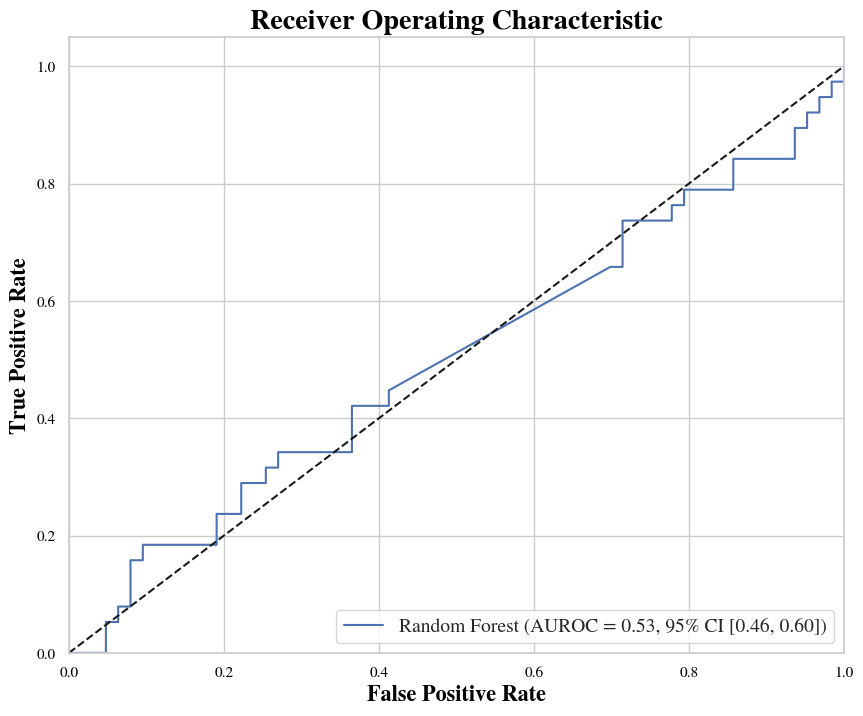

In [16]:
features = feature_importance_df['Feature'].loc[:8].to_list()

X_train_orig, y_train, y_train_ids = train[features], train['TB Label'], train['record_id']
X_valid, y_valid, y_valid_ids = valid[features], valid['TB Label'], valid['record_id']
X_test, y_test_m, y_test_ids = test[features], test['TB Label'], test['record_id']

# Combine train and validation sets for cross-validation
X_train_full = pd.concat([X_train_orig, X_valid])
y_train_full = pd.concat([y_train, y_valid])

# Standardize the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 7],
    'rf__min_samples_split': [2, 5, 10]
}
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

models = {
    'Random Forest': (rf_pipeline, param_grid_rf),
}

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

rf_folds_test_preds = pd.DataFrame()
rf_folds_test_preds['record_id'] = y_test_ids

folds_preds_df = pd.DataFrame()
folds_preds_df['record_id'] = y_test_ids
folds_preds_df['TB Label'] = y_test_m

results = {}
best_models = {}


for model_name, (pipeline, param_grid) in models.items():
    test_aurocs = []
    fold_predictions = []
    best_test_auc = 0
    for fold, (train_index, valid_index) in enumerate(skf.split(X_train_full, y_train_full)):
        X_train_fold, X_valid_fold = X_train_full[train_index], X_train_full[valid_index]
        y_train_fold, y_valid_fold = y_train_full.iloc[train_index], y_train_full.iloc[valid_index]
        
        grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                                   scoring='roc_auc', cv=5, n_jobs=-1, verbose=False)
        grid_search.fit(X_train_fold, y_train_fold)
        
        best_model = grid_search.best_estimator_

        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test_m, y_test_pred_proba)
        test_aurocs.append(test_auc)

        if test_auc > best_test_auc:
            best_models[model_name] = best_model

        folds_preds_df[f'{model_name}_Fold_{fold}'] = y_test_pred_proba

    
    mean_auc, ci_lower, ci_upper = mean_confidence_interval(test_aurocs)
    results[model_name] = (mean_auc, ci_lower, ci_upper)
    
    print(f"Model: {model_name}")
    print(f"Mean AUROC on Test Set: {mean_auc:.3f}")
    print(f"95% CI for AUROC on Test Set: [{ci_lower:.3f}, {ci_upper:.3f}]")

    predictions = {}
for model_name, (mean_auc, ci_lower, ci_upper) in results.items():
    model = best_models[model_name]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred_proba

# Save predictions to a file
with open('model_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Plot the AUROC curve

plt.figure(figsize=(10, 8))

results_df = pd.DataFrame({
    'record_id': y_test_ids,
    'y_test': y_test_m
})

for model_name, y_pred_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test_m, y_pred_proba)
    mean_auc, ci_lower, ci_upper = results[model_name]
    results_df[f'{model_name}_pred_proba'] = y_pred_proba
    results_df[f'{model_name}_fpr'] = pd.Series(fpr, index=results_df.index[:len(fpr)])
    results_df[f'{model_name}_tpr'] = pd.Series(tpr, index=results_df.index[:len(tpr)])
    plt.plot(fpr, tpr, label=f'{model_name} (AUROC = {mean_auc:.2f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}])')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('auroc_curve.png')
plt.show()